<a href="https://colab.research.google.com/github/BrunaDadona/Projeto-IA/blob/main/Projeto_IA_Malga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas scikit-learn matplotlib numpy


Saving student-por.csv to student-por (7).csv
Nome do arquivo carregado: student-por (7).csv
Número de atributos de entrada: 15

Treinando modelo ReLU...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Primeiros 20 erros (ReLU): [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
Acurácia modelo ReLU: 0.9000

Treinando modelo Tanh...



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Primeiros 20 erros (Tanh): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Acurácia modelo Tanh: 0.9077


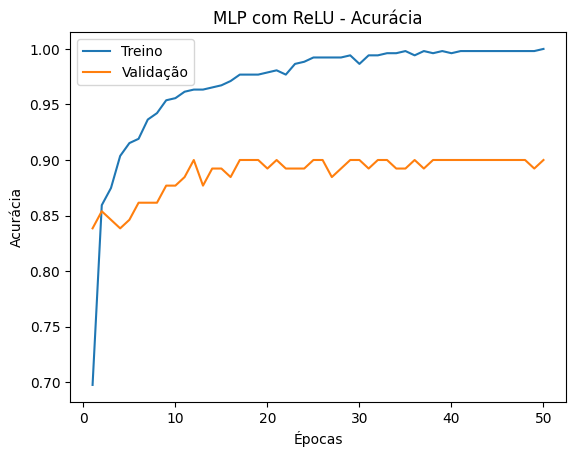

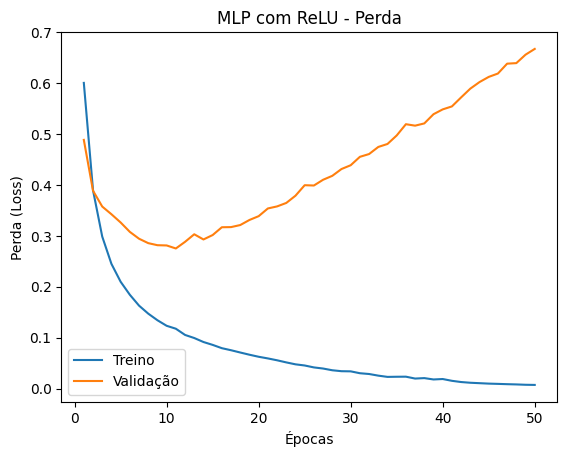

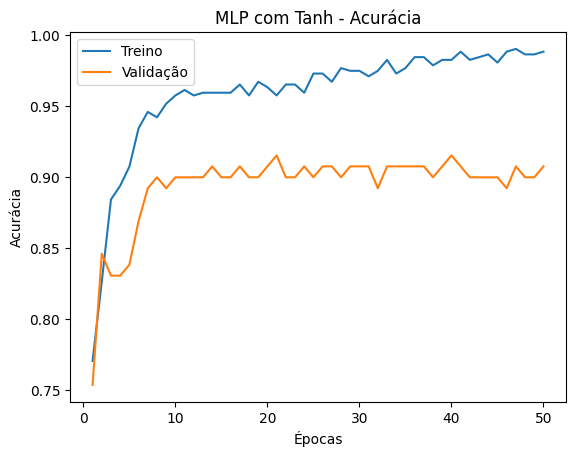

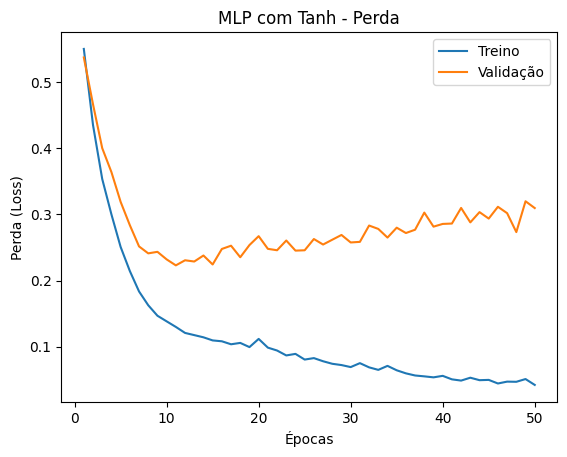


Treinamento concluído.


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import numpy as np

import io
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Nome do arquivo carregado:", filename)

df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=";")


# CRIAR VARIÁVEL APROVADO (1) / NÃO APROVADO (0)
df["APROVADO"] = (df["G3"] >= 10).astype(int)


# SELECIONAR ATRIBUTOS
cols_features = [
    "age", "sex", "Medu", "Fedu", "studytime", "failures", "schoolsup",
    "famsup", "absences", "freetime", "goout", "Dalc", "Walc", "G1", "G2"
]

X = df[cols_features]
y = df["APROVADO"]

# Transformar variáveis categóricas
X = pd.get_dummies(X, drop_first=True)


# DIVIDIR TREINO / TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Padronizar dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]
print(f"Número de atributos de entrada: {input_dim}")


# FUNÇÃO DE PLOT DOS GRÁFICOS
def plot_history(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    # Acurácia
    plt.figure()
    plt.plot(epochs_range, acc, label="Treino")
    plt.plot(epochs_range, val_acc, label="Validação")
    plt.xlabel("Épocas")
    plt.ylabel("Acurácia")
    plt.title(f"{title_prefix} - Acurácia")
    plt.legend()
    plt.show()

    # Perda
    plt.figure()
    plt.plot(epochs_range, loss, label="Treino")
    plt.plot(epochs_range, val_loss, label="Validação")
    plt.xlabel("Épocas")
    plt.ylabel("Perda (Loss)")
    plt.title(f"{title_prefix} - Perda")
    plt.legend()
    plt.show()


# DEFINIR HIPERPARÂMETROS
learning_rate = 0.001
epochs = 50
batch_size = 32

optimizer_relu = Adam(learning_rate=learning_rate)
optimizer_tanh = Adam(learning_rate=learning_rate)


# MODELO MLP COM RELU
model_relu = Sequential([
    Dense(64, activation="relu", input_shape=(input_dim,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_relu.compile(
    optimizer=optimizer_relu,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nTreinando modelo ReLU...\n")
history_relu = model_relu.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=0
)

# Predições do modelo ReLU
y_pred_proba_relu = model_relu.predict(X_test_scaled).flatten()
y_pred_relu = (y_pred_proba_relu >= 0.5).astype(int)

erros_relu = y_test.values - y_pred_relu
print("Primeiros 20 erros (ReLU):", erros_relu[:20])

acc_relu = accuracy_score(y_test, y_pred_relu)
print(f"Acurácia modelo ReLU: {acc_relu:.4f}")


# MODELO MLP COM TANH
model_tanh = Sequential([
    Dense(64, activation="tanh", input_shape=(input_dim,)),
    Dense(32, activation="tanh"),
    Dense(16, activation="tanh"),
    Dense(1, activation="sigmoid")
])

model_tanh.compile(
    optimizer=optimizer_tanh,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nTreinando modelo Tanh...\n")
history_tanh = model_tanh.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=0
)

# Predições do modelo Tanh
y_pred_proba_tanh = model_tanh.predict(X_test_scaled).flatten()
y_pred_tanh = (y_pred_proba_tanh >= 0.5).astype(int)

erros_tanh = y_test.values - y_pred_tanh
print("Primeiros 20 erros (Tanh):", erros_tanh[:20])

acc_tanh = accuracy_score(y_test, y_pred_tanh)
print(f"Acurácia modelo Tanh: {acc_tanh:.4f}")


# PLOTAR GRÁFICOS
plot_history(history_relu, "MLP com ReLU")
plot_history(history_tanh, "MLP com Tanh")

print("\nTreinamento concluído.")
